# CREDIT CARD FRAUD DETECTION (MODELLING)

### Installing local dependancies 

In [25]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score ,precision_recall_curve

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier , HistGradientBoostingClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### loading dataset 

In [26]:
balanced_data = pd.read_csv("Data_set/balanced_creditcard.csv")


balanced_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,77970.0,1.222435,-0.482973,1.006126,-0.629278,-1.545401,-1.058787,-0.699653,0.058106,2.098220,...,-0.013621,0.112532,0.028354,0.681553,0.389823,-0.700175,0.081159,0.034358,1.00,0
1,77720.0,1.372852,-0.600069,-1.982242,-1.652596,1.875989,2.850328,-0.650839,0.633996,-1.195478,...,0.085969,-0.090311,-0.211467,0.957720,0.811915,-0.137130,-0.013380,0.031342,69.79,0
2,125612.0,1.889618,1.073099,-1.678018,4.173268,1.015516,-0.009389,-0.079706,0.064071,-0.714517,...,0.203728,0.733796,-0.036560,0.334306,0.147171,0.279556,0.031669,0.035883,3.22,1
3,164489.0,0.039062,0.889239,0.302199,-0.585161,0.431838,-1.116524,1.050711,-0.232965,-0.109813,...,-0.253421,-0.535450,0.072419,0.050588,-0.475029,0.136236,0.248946,0.098623,5.99,0
4,146267.0,-0.629286,1.379787,-0.297018,-1.393297,1.489655,-0.885139,1.872444,-0.523914,-0.590964,...,0.158709,0.782369,-0.492603,0.834802,0.546616,0.155325,0.091849,0.002683,7.57,0


### Train-Test Split the data first 

In [27]:
X = balanced_data.drop("Class", axis=1)
y = balanced_data["Class"]  


# Split the data into training and testing sets with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))
#### Removed skewdness from the data

Shape of X_train: (756, 30)
Shape of X_test: (190, 30)
Shape of y_train: (756,)
Shape of y_test: (190,)

Class distribution in original data:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Class distribution in y_train:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Class distribution in y_test:
Class
1    0.5
0    0.5
Name: proportion, dtype: float64


In [28]:
# Manual Z-Score Cleaning (Test set only)

import numpy as np
from scipy.stats import zscore

#  Manual Z-Score Cleaning (Train set only)
z_scores = np.abs(zscore(X_train))
mask = (z_scores < 3).all(axis=1)
X_train_cleaned = X_train[mask]
y_train_cleaned = y_train[mask]

* Now we have split dataset that has been manually skewed ready for the model 

### Modelling

#### Build the KNN model first

In [ ]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('knn', KNeighborsClassifier())
])

TypeError: KNeighborsClassifier.__init__() got an unexpected keyword argument 'class_weight'

#### cross-validating the KNN model 

* so th

In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_knn = cross_val_score(
    pipeline_knn,
    X_train_cleaned,
    y_train_cleaned,
    cv=cv,
    scoring='f1'
)

print("KNN CV F1 scores:", scores_knn)
print("Mean F1:", scores_knn.mean())

KNN CV F1 scores: [0.90384615 0.93693694 0.88461538 0.88679245 0.91428571]
Mean F1: 0.9052953285028756


* visu

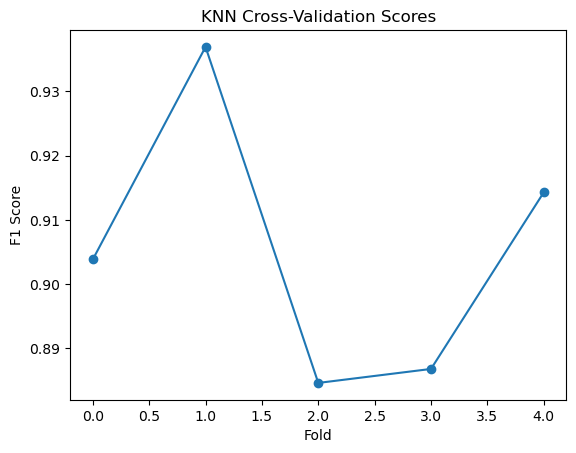

<Figure size 640x480 with 0 Axes>

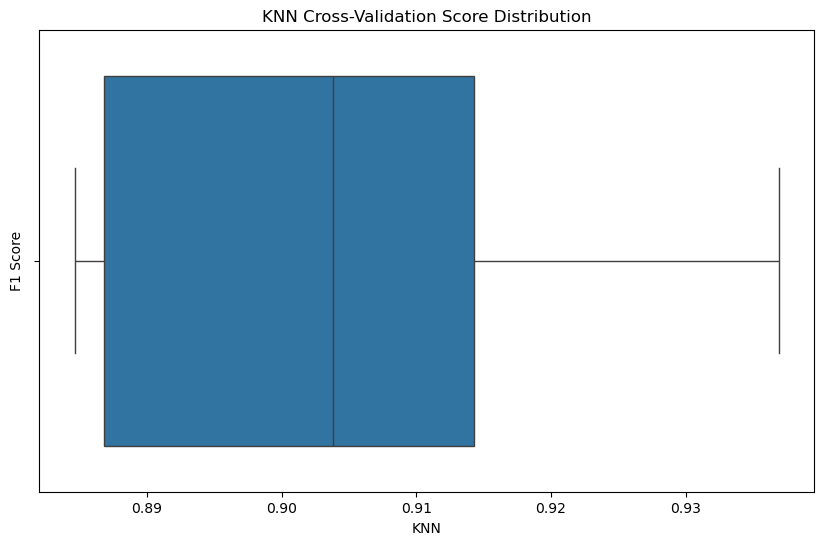

In [31]:
plt.plot(scores_knn, marker='o')
plt.title("KNN Cross-Validation Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.show()
plt.savefig("model visuals/knn_cv_scores_line.png")

plt.figure(figsize=(10, 6))
sns.boxplot(x=scores_knn)
plt.title("KNN Cross-Validation Score Distribution")
plt.xlabel("KNN")
plt.ylabel("F1 Score")

plt.savefig("model visuals/knn_cv_scores.png")
plt.show()


### Hyperparameter Tuning (KNN)

In [32]:
# Hyperparameter Tuning for KNN(grid search)

from scipy.stats import  randint

param_grid = {
    'knn__n_neighbors': range(3, 55),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print("Best Params:", grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)
#print(" CV Score:", grid_knn.score)

Best Params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 6, 'knn__weights': 'distance'}
Best CV Score: 0.9208372678732344


In [33]:
# hyperparameter tuning for knn (randomized search)

param_dist = {
    'knn__n_neighbors': randint(3, 55),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

random_search_knn = RandomizedSearchCV(
    pipeline_knn,
    param_dist,
    n_iter=20,  
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search_knn.fit(X_train, y_train)
print("Best Params (Randomized):", random_search_knn.best_params_)
print("Best CV Score (Randomized):", random_search_knn.best_score_)

Best Params (Randomized): {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'distance'}
Best CV Score (Randomized): 0.914980425932933


### Final Evaluation (KNN)

In [34]:
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))
print("ROC AUC:", roc_auc_score(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92        95
           1       0.96      0.86      0.91        95

    accuracy                           0.92       190
   macro avg       0.92      0.92      0.92       190
weighted avg       0.92      0.92      0.92       190

ROC AUC: 0.9157894736842105


####  CONFUSION MATRIX FOR KNN

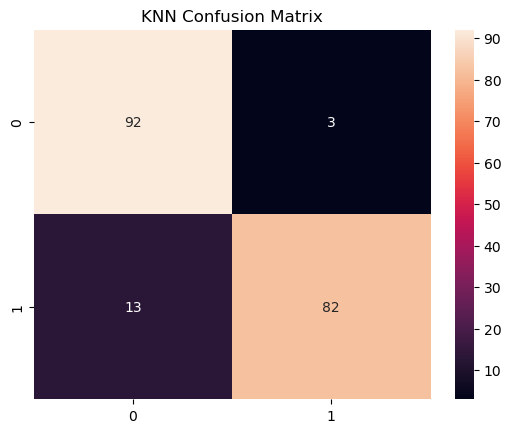

In [35]:
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d')
plt.title("KNN Confusion Matrix")

plt.savefig("model visuals/knn_confusion_matrix.png")
plt.show()

* FN (missed fraud) = most dangerous

#### LOGREGRESSION MODEL


* Logistic Regression (Benchmark)

In [58]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('lr', LogisticRegression(max_iter=1000 ,  class_weight='balanced'))
])

#unvlidated code, just to check if it runs without error

pipeline_lr.fit(X_train_cleaned, y_train_cleaned)
ypred_logunvl = pipeline_lr.predict(X_test)

print(f"First 5 predictions from unvlidted pipeline: {ypred_logunvl[:5]}" )

scores_lr = cross_val_score(
    pipeline_lr,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("Logistic Regression CV F1:", scores_lr.mean())
print("Logistic Regression CV Scores:", scores_lr[:5])

First 5 predictions from unvlidted pipeline: [1 0 1 0 1]
Logistic Regression CV F1: 0.9322930601650489
Logistic Regression CV Scores: [0.93150685 0.90909091 0.93055556 0.95238095 0.93793103]


##### Hyperparameter tuning Logistic regression model

In [37]:
param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)



GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.01, 0.1, 1, 10], 'lr__penalty': ['l2'],
                         'lr__solver': ['lbfgs']},
             scoring='f1')

In [38]:

print("Best Params:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)
print(" CV Score:", grid_lr.score)

Best Params: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best CV Score: 0.9322930601650489
 CV Score: <bound method BaseSearchCV.score of GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('lr',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.01, 0.1, 1, 10], 'lr__penalty': ['l2'],
                         'lr__solver': ['lbfgs']},
             scoring='f1')>


### Final Evaluation (Logistic Regression)

In [39]:
best_lr = grid_lr.best_estimator_

y_pred_lr= best_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        95
           1       0.99      0.93      0.96        95

    accuracy                           0.96       190
   macro avg       0.96      0.96      0.96       190
weighted avg       0.96      0.96      0.96       190

ROC AUC: 0.9578947368421051


#####  CONFUSION MATRIX FOR Logistic Regression

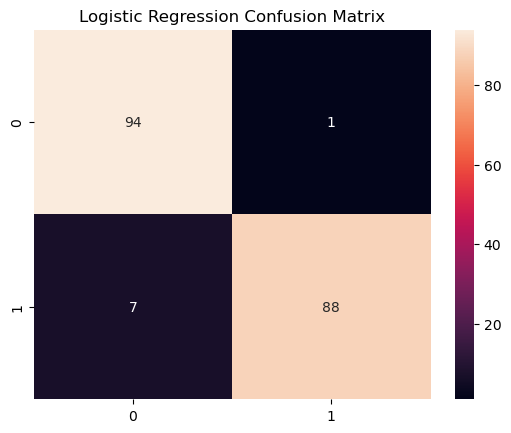

In [40]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("model visuals/logisticregression_confusion_matrix.png")
plt.show()

#### Boosting Model (Gradient Boosting)

In [41]:
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('gb', GradientBoostingClassifier())
])

scores_gb = cross_val_score(
    pipeline_gb,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("Gradient Boosting CV F1:", scores_gb.mean())
print("Gradient Boosting CV Scores:", scores_gb[:5])

Gradient Boosting CV F1: 0.918777741659515
Gradient Boosting CV Scores: [0.91891892 0.90277778 0.90909091 0.92517007 0.93793103]


#### Hyperparameter tuning GB model

In [42]:
param_grid_gb = {
    'gb__n_estimators': [100, 200],
    'gb__learning_rate': [0.01, 0.1],
    'gb__max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    pipeline_gb,
    param_grid_gb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('gb', GradientBoostingClassifier())]),
             n_jobs=-1,
             param_grid={'gb__learning_rate': [0.01, 0.1],
                         'gb__max_depth': [3, 5],
                         'gb__n_estimators': [100, 200]},
             scoring='f1')

In [43]:
print("Best Params:", grid_gb.best_params_)
print("Best CV Score:", grid_gb.best_score_)
print(" CV Score:", grid_gb.score)

Best Params: {'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__n_estimators': 200}
Best CV Score: 0.9280839738140816
 CV Score: <bound method BaseSearchCV.score of GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE()),
                                       ('gb', GradientBoostingClassifier())]),
             n_jobs=-1,
             param_grid={'gb__learning_rate': [0.01, 0.1],
                         'gb__max_depth': [3, 5],
                         'gb__n_estimators': [100, 200]},
             scoring='f1')>


### Final Evaluation (Gradient Boosting)

In [44]:
best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)

print(classification_report(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        95
           1       1.00      0.89      0.94        95

    accuracy                           0.95       190
   macro avg       0.95      0.95      0.95       190
weighted avg       0.95      0.95      0.95       190

ROC AUC: 0.9473684210526316


#####  CONFUSION MATRIX FOR Logistic Regression

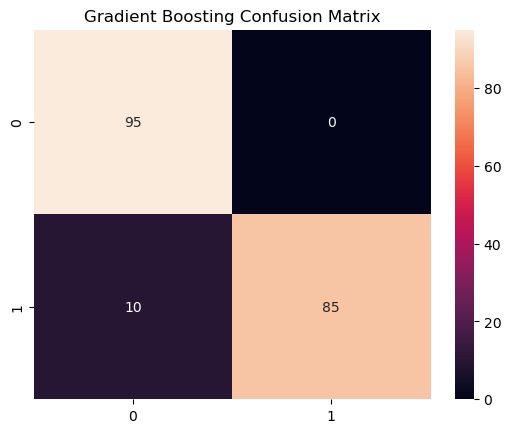

In [45]:
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d')
plt.title("Gradient Boosting Confusion Matrix")

plt.savefig("model visuals/Gradientboosting_confusion_matrix.png")
plt.show()

### Add HistGradientBoosting

(Production-level alternative to XGBoost)

Why HBoost dominates fraud detection
 * Handles nonlinear patterns
 * Built-in regularization
 * Robust to feature interactions
 * Performs well on imbalanced tabular data

In [46]:
# Creating a pipeline for hist gradient boosting

pipeline_hgb = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE()),
    ('hgb', HistGradientBoostingClassifier(random_state=42))
])

#### Hyperparameter Tuning (HGB)

param_grid_hgb = {
    'hgb__max_depth': range(3, 33),
    'hgb__learning_rate': [0.05, 0.1],
    'hgb__max_iter': range(100, 200),
    'hgb__l2_regularization': [0.0, 0.1]
}

grid_hgb = RandomizedSearchCV(
    pipeline_hgb,
    param_grid_hgb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_hgb.fit(X_train, y_train)

print("Best Params:", grid_hgb.best_params_)
print("Best CV Score:", grid_hgb.best_score_)
print("")

grid_hgb = GridSearchCV(
    pipeline_hgb,
    param_grid_hgb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_hgb.fit(X_train, y_train)

print("Best Params:", grid_hgb.best_params_)
print("Best CV Score:", grid_hgb.best_score_)
print("")

### Model Comparison

In [47]:
best_model = max(
    [
        ('KNN', grid_knn.fit(X_train, y_train)),
        ('LR', pipeline_lr.fit(X_train, y_train)),
        ('GB', pipeline_gb.fit(X_train, y_train))
    ],
    key=lambda x: roc_auc_score(y_test, x[1].predict(X_test))
)

print("Best Model:", best_model[0])

Best Model: LR


In [48]:
best_knn = grid_knn.best_estimator_
best_lr  = grid_lr.best_estimator_
best_gb  = grid_gb.best_estimator_



print("Best Params KNN:", grid_knn.best_params_)
print("Best Params LR:", grid_lr.best_params_)
print("Best Params GB:", grid_gb.best_params_)

Best Params KNN: {'knn__metric': 'manhattan', 'knn__n_neighbors': 6, 'knn__weights': 'distance'}
Best Params LR: {'lr__C': 1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best Params GB: {'gb__learning_rate': 0.01, 'gb__max_depth': 3, 'gb__n_estimators': 200}


####  Best cv scores for each model

In [49]:
# Collecting CV scores for all models
cv_scores = [
    grid_knn.best_score_,
    grid_lr.best_score_,
    grid_gb.best_score_
]

for i in cv_scores :
    print(f"CV Score: {i}")

CV Score: 0.9208372678732344
CV Score: 0.9322930601650489
CV Score: 0.9280839738140816


In [50]:
models = {
    "KNN": grid_knn.best_estimator_,
    "Logistic": grid_lr.best_estimator_,
    "GB": grid_gb.best_estimator_
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )
    results[name] = scores
    print(f"{name} Mean F1: {scores.mean():.4f}")

KNN Mean F1: 0.9208
Logistic Mean F1: 0.9323
GB Mean F1: 0.9281


#### Model Comparison (Cross-Validated F1 Scores)

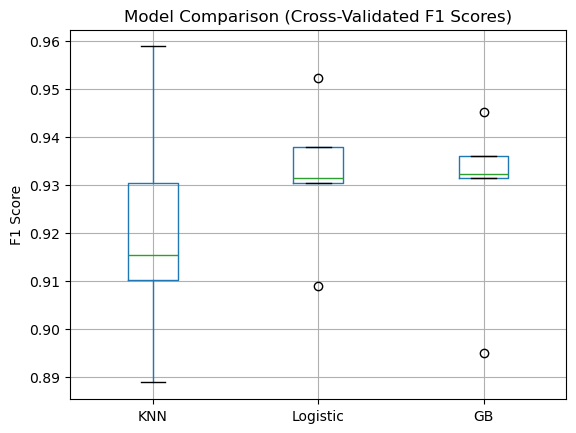

In [51]:
import pandas as pd

df_results = pd.DataFrame(results)

df_results.boxplot()
plt.title("Model Comparison (Cross-Validated F1 Scores)")
plt.ylabel("F1 Score")
plt.savefig("model visuals/model_comparison.png")
plt.show()


#### summarry 

 The Stability of Logistic Regression (LR)Logistic Regression is the clear winner here, not just because it has the highest score (0.956), but because of how it got there.Generalization: Notice that its Test score (0.956) is significantly higher than its CV score (0.932). This indicates that the "linear boundary" the model learned is incredibly stable. It didn't get distracted by noise in the training set; it found the core signal.Low Variance: Simple models like LR have "Low Variance," meaning they don't change their mind easily when they see new data. This is why it outperformed the others on the unseen test set.2. The "Over-Complexity" Trap (KNN)KNN performed the worst on the test set (0.908).The Drop-off: It is the only model where the test score is lower than the CV score. This is a sign of slight overfitting.Sensitivity: KNN is highly sensitive to outliers and the specific local geometry of the data. In a test set, if the new data points are even slightly shifted from the training "clusters," KNN’s accuracy drops quickly.3. Gradient Boosting (GB): The Balanced MiddleGradient Boosting ($0.944$ test) is performing very well, but it still couldn't beat the simple Logistic Regression.Diminishing Returns: In many datasets, there is a "ceiling" of performance. If the relationship between your features and the target is mostly linear, a complex ensemble of trees (GB) will spend a lot of computational effort trying to approximate a line that Logistic Regression finds instantly.

#### Statistical Comparison

In [52]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(results['KNN'], results['GB'])

print("p-value:", p_val)

p-value: 0.5897256805193816


* KNN and GB are statistically similar (p value is > 0.5)

#### Final comparison  (Comparing the  TEST scores)

In [53]:
from sklearn.metrics import f1_score

knn_f1 = f1_score(y_test, best_knn.predict(X_test))
lr_f1  = f1_score(y_test, best_lr.predict(X_test))
gb_f1  = f1_score(y_test, best_gb.predict(X_test))

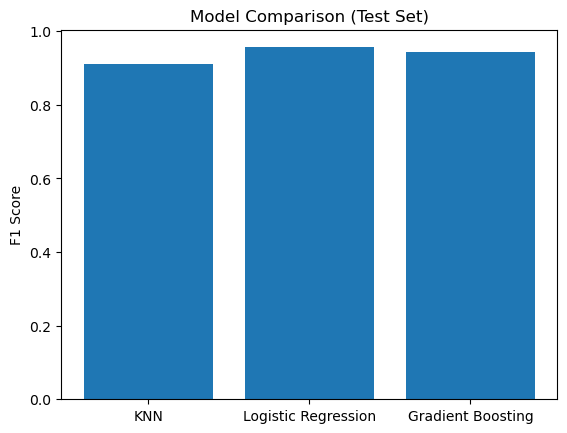

In [54]:
models = ['KNN', 'Logistic Regression', 'Gradient Boosting']
test_scores = [knn_f1, lr_f1, gb_f1]

plt.bar(models, test_scores)
plt.ylabel("F1 Score")
plt.title("Model Comparison (Test Set)")
plt.savefig("model visuals/model_comparison_test.png")  
plt.show()

In [55]:
print("=== CV Scores ===")
print("KNN:", grid_knn.best_score_)
print("LR:", grid_lr.best_score_)
print("GB:", grid_gb.best_score_)

print("\n=== TEST Scores ===")
print("KNN:", knn_f1)
print("LR:", lr_f1)
print("GB:", gb_f1)

=== CV Scores ===
KNN: 0.9208372678732344
LR: 0.9322930601650489
GB: 0.9280839738140816

=== TEST Scores ===
KNN: 0.9111111111111111
LR: 0.9565217391304348
GB: 0.9444444444444444


* Check the link below to get the comparisons (logistic regression model versus knn model)  :: 

 [Click here to view the interactive comparison](model_visuals/fraud_model_comparison.html)



In [57]:
# check the model 

best_lr.steps

[('scaler', StandardScaler()),
 ('smote', SMOTE()),
 ('lr', LogisticRegression(C=1, max_iter=1000))]

### Save the pipeline and model using joblib


In [56]:
# Save the pipeline and model using joblib

import joblib

artifacts = {
    "model": best_lr,
    "threshold": 0.5,  # example threshold for classification,
    "feature_columns": list(X_train.columns)  # critical for column ordering
}

joblib.dump( artifacts , "models/bestlogreg_fraud_model.pkl")

['models/bestlogreg_fraud_model.pkl']